# NISRA Case Updates Over Time
Authenticate first, then run this notebook to query NISRA case updates over time.

## Import required libraries
This notebook uses shared helpers from the repository and standard data/plotting libraries.

In [1]:
from pathlib import Path
import sys
from datetime import datetime, timedelta, timezone

from google.api_core.exceptions import ResourceExhausted
import pandas as pd
import matplotlib.pyplot as plt
import time

repo_root = Path.cwd()
if not (repo_root / "src" / "helpers").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from helpers.logging_client import get_logs_client

## Create a client
Before running this notebook, authenticate with Application Default Credentials:
1. Run `gcloud auth application-default login`
2. Run `gcloud config set project <project-id>`
Then run the client cell below to connect to Cloud Logging.

In [2]:
logs = get_logs_client()

## Query configuration
Choose either `lookback_hours` for a relative time-ago window, or explicit `start_timestamp`/`end_timestamp`.

In [3]:
# Query options
lookback_hours = 24
start_timestamp = None  # Example: "2026-06-30T00:00:00Z"
end_timestamp = None  # Example: "2026-07-01T00:00:00Z"
max_results = None  # Set to None to remove explicit cap
page_size = 1000

if lookback_hours is not None and (start_timestamp is not None or end_timestamp is not None):
    raise ValueError("Use either lookback_hours or start/end timestamps, not both.")

if lookback_hours is not None:
    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(hours=lookback_hours)
    start_timestamp = start_dt.isoformat().replace("+00:00", "Z")
    end_timestamp = end_dt.isoformat().replace("+00:00", "Z")

time_parts = []
if start_timestamp is not None:
    time_parts.append(f'timestamp>="{start_timestamp}"')
if end_timestamp is not None:
    time_parts.append(f'timestamp<="{end_timestamp}"')

time_clause = " AND ".join(time_parts) if time_parts else ""

message_clauses = [
    '"RESTAPI: NISRA case \'"',
    '" was successfully updated for questionnaire \'"',
    'jsonPayload.source_name="Rest API"',
]
base_filter = " AND ".join(message_clauses)
log_filter = f"{base_filter} AND {time_clause}" if time_clause else base_filter

list_entries_kwargs = {
    "filter_": log_filter,
    "page_size": page_size,
}
if max_results is not None:
    list_entries_kwargs["max_results"] = max_results

print(f"Filter: {log_filter}")
print(f"max_results: {max_results}")
print(f"page_size: {page_size}")

Filter: "RESTAPI: NISRA case '" AND " was successfully updated for questionnaire '" AND jsonPayload.source_name="Rest API" AND timestamp>="2026-06-30T13:42:49.223723Z" AND timestamp<="2026-07-01T13:42:49.223723Z"
max_results: None
page_size: 1000


## Fetch entries
Read entries with retry support for temporary quota errors.

In [4]:
entries = []
attempt = 0
max_attempts = 5

while attempt < max_attempts:
    try:
        results = logs.list_entries(**list_entries_kwargs)
        entries = []
        for result in results:
            payload = result.payload
            message = ""

            if isinstance(payload, dict):
                message = str(payload.get("message", ""))
            else:
                message = str(payload)

            entries.append(
                dict(
                    timestamp=result.timestamp,
                    message=message,
                )
            )
        break
    except ResourceExhausted:
        attempt += 1
        if attempt >= max_attempts:
            raise
        wait_seconds = 2**attempt
        print(f"Read quota hit, retrying in {wait_seconds}s...")
        time.sleep(wait_seconds)

print(f"Fetched entries: {len(entries)}")

Fetched entries: 2278


## Build hourly counts
Create three hourly series: all matched events, `'opn'` subset, and `'lms'` subset.

In [5]:
entries_df = pd.DataFrame(entries, columns=["timestamp", "message"])
if entries_df.empty:
    raise ValueError(
        "No matching entries found for this time window. Try increasing lookback_hours or changing timestamps."
    )

entries_df["timestamp"] = pd.to_datetime(entries_df["timestamp"], utc=True)

all_hourly = (
    entries_df.set_index("timestamp")
    .resample("h")
    .size()
    .rename("count")
    .reset_index()
)

opn_df = entries_df[entries_df["message"].str.contains("'opn", case=False, na=False)]
lms_df = entries_df[entries_df["message"].str.contains("'lms", case=False, na=False)]

opn_hourly = (
    opn_df.set_index("timestamp")
    .resample("h")
    .size()
    .rename("count")
    .reset_index()
)

lms_hourly = (
    lms_df.set_index("timestamp")
    .resample("h")
    .size()
    .rename("count")
    .reset_index()
)

print(f"All matched entries: {len(entries_df)}")
print(f"Entries containing 'opn': {len(opn_df)}")
print(f"Entries containing 'lms': {len(lms_df)}")

All matched entries: 2278
Entries containing 'opn': 153
Entries containing 'lms': 2099


## Plot hourly scatter charts
Three scatter charts are shown: all events, `'opn'` events, and `'lms'` events.

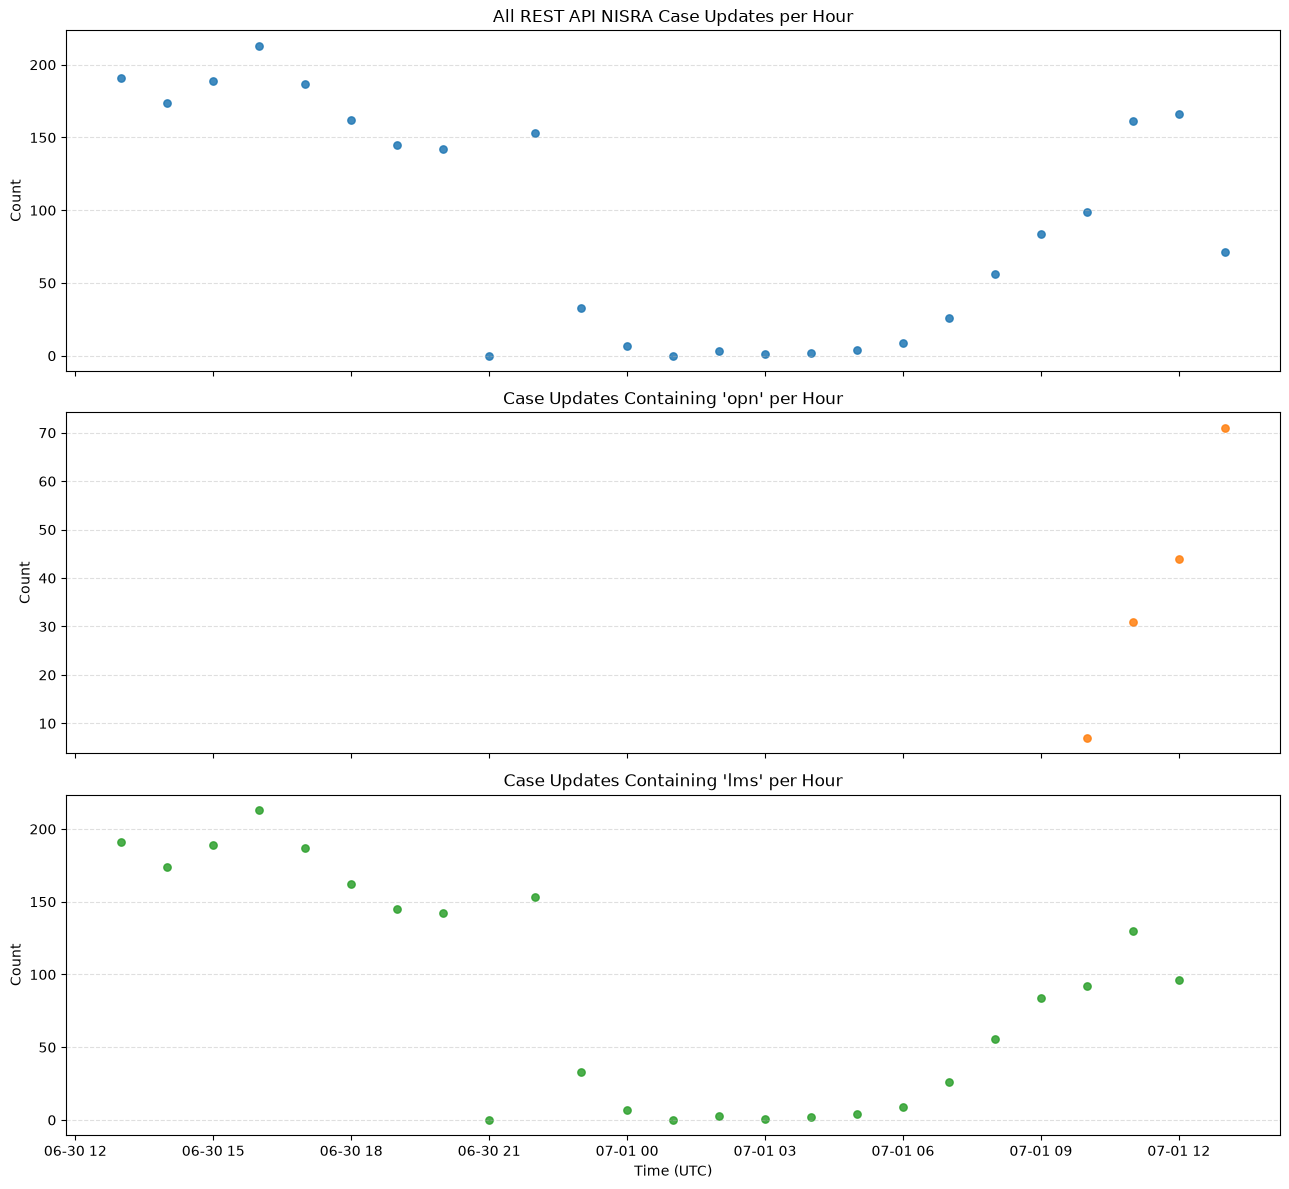

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

axes[0].scatter(all_hourly["timestamp"], all_hourly["count"], color="#1f77b4", s=28, alpha=0.85)
axes[0].set_title("NISRA Case Updates per Hour")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].scatter(opn_hourly["timestamp"], opn_hourly["count"], color="#ff7f0e", s=28, alpha=0.85)
axes[1].set_title("NISRA Case Updates Containing 'opn' per Hour")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

axes[2].scatter(lms_hourly["timestamp"], lms_hourly["count"], color="#2ca02c", s=28, alpha=0.85)
axes[2].set_title("NISRA Case Updates Containing 'lms' per Hour")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Time (UTC)")
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()